# Unzip dataset

In [1]:
!unzip '/content/mango_leaf-8-class.zip'

Archive:  /content/mango_leaf-8-class.zip
   creating: mango_leaf/New folder/
   creating: mango_leaf/New folder/Anthracnose/
  inflating: mango_leaf/New folder/Anthracnose/20211008_124249 (Custom).jpg  
  inflating: mango_leaf/New folder/Anthracnose/20211008_124250 (Custom).jpg  
  inflating: mango_leaf/New folder/Anthracnose/20211008_124252 (Custom).jpg  
  inflating: mango_leaf/New folder/Anthracnose/20211008_124253 (Custom).jpg  
  inflating: mango_leaf/New folder/Anthracnose/20211008_124256 (Custom).jpg  
  inflating: mango_leaf/New folder/Anthracnose/20211008_124301 (Custom).jpg  
  inflating: mango_leaf/New folder/Anthracnose/20211008_124302 (Custom).jpg  
  inflating: mango_leaf/New folder/Anthracnose/20211008_124305 (Custom).jpg  
  inflating: mango_leaf/New folder/Anthracnose/20211008_124306 (Custom).jpg  
  inflating: mango_leaf/New folder/Anthracnose/20211008_124310 (Custom).jpg  
  inflating: mango_leaf/New folder/Anthracnose/20211008_124312 (Custom).jpg  
  inflating: man

# import library

In [2]:
import os
import shutil
import random

import numpy as np
from skimage import io
from PIL import Image
from keras.preprocessing import image

import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from skimage import io
import numpy as np
import os
from PIL import Image
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
# Import Data Science Libraries
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
import itertools
import random

# Import visualization libraries
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2

# Tensorflow Libraries
from tensorflow import keras
from tensorflow.keras import layers,models
from keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import Callback, EarlyStopping,ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Model

# System libraries
from pathlib import Path
import os.path
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

import warnings
warnings.filterwarnings('ignore')
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
import skimage
from skimage.transform import resize
# label binarizer
from sklearn.preprocessing import LabelBinarizer
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

# Metrics
from sklearn.metrics import classification_report, confusion_matrix

## Split data into main and test validation

In [3]:
from ast import main
# Define your dataset directories and the directories where you want to create the splits:

dataset_dir = "/content/mango_leaf/New folder"  # Replace with the path to your dataset
main_dir = "train_set"
test_dir = "test_set"

# Create the train, test, and validation directories if they don't exist
os.makedirs(main_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

In [4]:
# Set the split ratio (for main 80% , for test 20%)

main_ratio = 0.80
test_ratio = 0.20

In [5]:
# iterate throught the folders containing our two type of data and splite them into main and test

for class_folder in os.listdir(dataset_dir):
    class_path = os.path.join(dataset_dir, class_folder)

    if os.path.isdir(class_path):
        file_list = os.listdir(class_path)
        random.shuffle(file_list)

        main_split = int(len(file_list) * main_ratio)
        test_split = int(len(file_list) * (main_ratio + test_ratio))

        main_files = file_list[:main_split]
        test_files = file_list[main_split:test_split]


        for file_name in main_files:
            src = os.path.join(class_path, file_name)
            dst = os.path.join(main_dir, class_folder, file_name)
            os.makedirs(os.path.dirname(dst), exist_ok=True)
            shutil.copy(src, dst)

        for file_name in test_files:
            src = os.path.join(class_path, file_name)
            dst = os.path.join(test_dir, class_folder, file_name)
            os.makedirs(os.path.dirname(dst), exist_ok=True)
            shutil.copy(src, dst)



## run

In [6]:
# data
train_dir = '/content/train_set'
test_dir = '/content/test_set'
# Define constants
batch_size = 32
image_size = (224, 224)


In [7]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'  # Use the training split
)
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'  # Use the validation split
)

Found 2560 images belonging to 8 classes.
Found 640 images belonging to 8 classes.


In [8]:

test_datagen = ImageDataGenerator(rescale=1.0 / 255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=image_size,
    batch_size = batch_size,
    class_mode = 'categorical',
    shuffle = False


)

Found 800 images belonging to 8 classes.


# mobilenetv2

In [ ]:
# library

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Load pre-trained VGG16 model
model_MobileNetV2 = MobileNetV2(weights='imagenet',
                   include_top=False,
                   input_shape=(224, 224, 3))

for layer in model_MobileNetV2.layers:
    layer.trainable = False


# Build custom classification head
m1 = Sequential()
m1.add(model_MobileNetV2)
m1.add(Flatten())
m1.add(Dense(256, activation='relu'))
m1.add(Dropout(0.5))
m1.add(Dense(8, activation='softmax'))

# Compile the model
optimizer = Adam(learning_rate=0.001)


m1.compile(loss='categorical_crossentropy',
              optimizer=optimizer,
              metrics=['accuracy'])

# Train the model
history_m1 = m1.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator
)



Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 22s 104ms/step - accuracy: 0.6463 - loss: 5.7454 - val_accuracy: 0.8828 - val_loss: 0.3846
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.8921 - loss: 0.3279 - val_accuracy: 0.9062 - val_loss: 0.2727
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.9403 - loss: 0.2592 - val_accuracy: 0.9297 - val_loss: 0.2495
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.9412 - loss: 0.1971 - val_accuracy: 0.9625 - val_loss: 0.1613
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 105ms/step - accuracy: 0.9433 - loss: 0.2068 - val_accuracy: 0.9422 - val_loss: 0.2070
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.9408 - loss: 0.1926 - val_accuracy: 0.9109 - val_loss: 0.3426
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 17s 141ms/step - accuracy: 0.9425 - loss: 0.2258 - val_accuracy: 0.9375 - val_loss: 0.2998
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step - accuracy: 0.9505 - loss: 0.1439 - val_accuracy: 0.

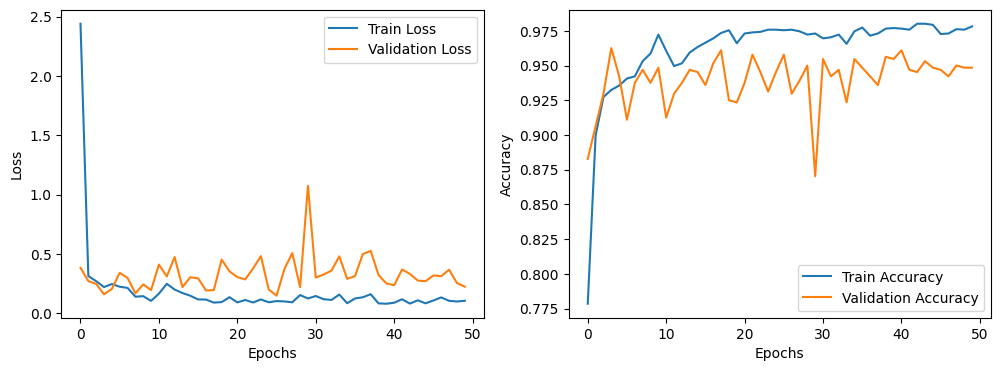

In [ ]:
 # Visualize training and validation loss and accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_m1.history['loss'], label='Train Loss')
plt.plot(history_m1.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_m1.history['accuracy'], label='Train Accuracy')
plt.plot(history_m1.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
# Generate predictions for the test set
predictions_m1 = m1.predict(test_generator)

# Use the true labels directly
y_true_m1 = test_generator.labels

# Convert predicted probabilities to class labels
y_pred_m1 = np.argmax(predictions_m1, axis=1)

# Classification Report
class_report_m1 = classification_report(y_true_m1, y_pred_m1)
print("Classification Report:")
print(class_report_m1)

25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       100
           1       0.99      1.00      1.00       100
           2       1.00      1.00      1.00       100
           3       0.99      1.00      1.00       100
           4       0.92      0.95      0.94       100
           5       0.97      0.99      0.98       100
           6       1.00      0.94      0.97       100
           7       0.95      0.97      0.96       100

    accuracy                           0.97       800
   macro avg       0.98      0.97      0.98       800
weighted avg       0.98      0.97      0.98       800



In [ ]:
from sklearn.metrics import accuracy_score

# Calculate the accuracy
accuracy_m1 = accuracy_score(y_true_m1, y_pred_m1)

# Print the accuracy
print("Accuracy:", accuracy_m1)

Accuracy: 0.975


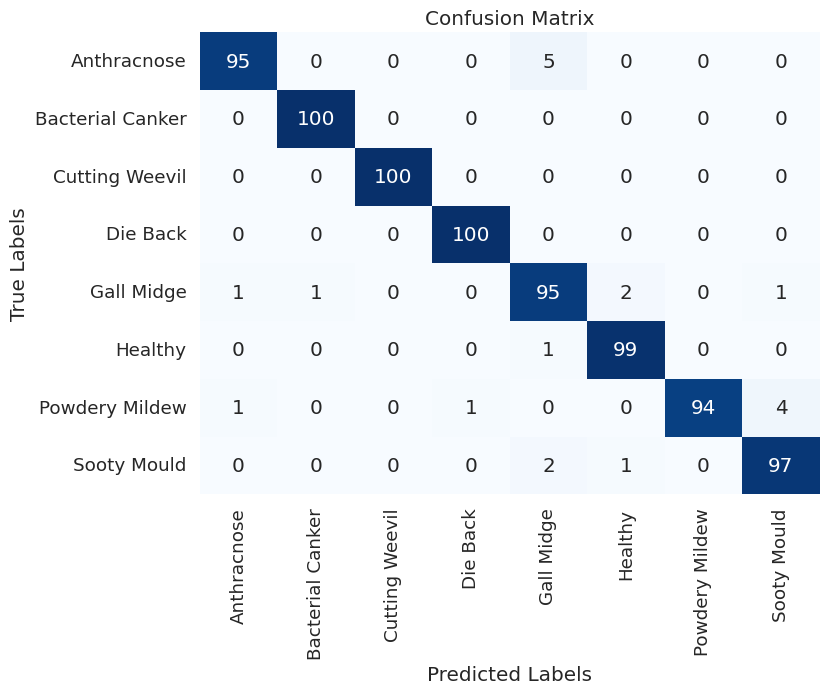

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
confusion_m1= confusion_matrix(y_true_m1, y_pred_m1)

# Define class labels (you can get them from the generator)
class_labels = list(test_generator.class_indices.keys())

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)
sns.heatmap(confusion_m1, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step


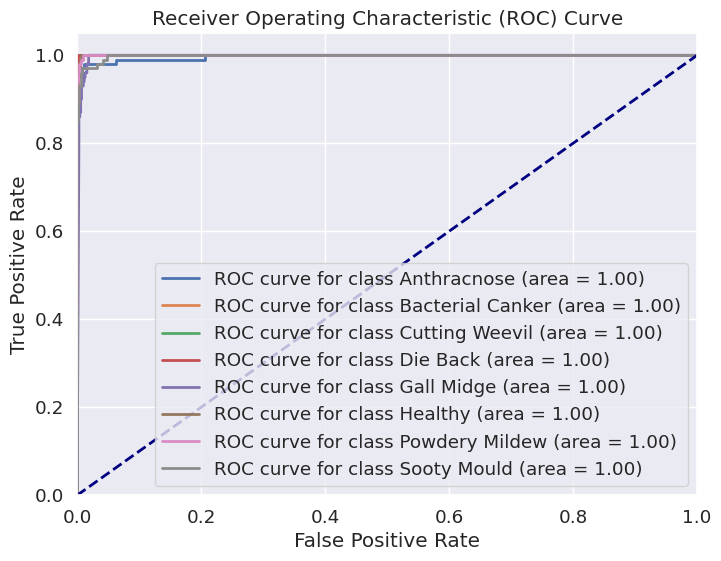

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Generate predictions for the test set
predictions_m1 = m1.predict(test_generator)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(class_labels)):
    fpr[i], tpr[i], _ = roc_curve(y_true_m1, predictions_m1[:, i], pos_label=i)
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting the ROC curve
plt.figure(figsize=(8, 6))
for i in range(len(class_labels)):
    plt.plot(fpr[i], tpr[i], lw=2, label='ROC curve for class {0} (area = {1:0.2f})'.format(class_labels[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


In [ ]:
m1.save('model.h5')

# NASNetMobile

In [ ]:
# library

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import NASNetMobile
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Load pre-trained VGG16 model
model_NASNetMobile = NASNetMobile(weights='imagenet',
                   include_top=False,
                   input_shape=(224, 224, 3))

for layer in model_NASNetMobile.layers:
    layer.trainable = False


# Build custom classification head
m2 = Sequential()
m2.add(model_NASNetMobile)
m2.add(Flatten())
m2.add(Dense(256, activation='relu'))
m2.add(Dropout(0.5))
m2.add(Dense(8, activation='softmax'))

# Compile the model
optimizer = Adam(learning_rate=0.001)


m2.compile(loss='categorical_crossentropy',
              optimizer=optimizer,
              metrics=['accuracy'])

# Train the model
history_m2 = m2.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator
)



19993432/19993432 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 56s 271ms/step - accuracy: 0.6168 - loss: 5.2017 - val_accuracy: 0.9266 - val_loss: 0.2839
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 14s 89ms/step - accuracy: 0.8906 - loss: 0.3332 - val_accuracy: 0.9250 - val_loss: 0.2619
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - accuracy: 0.9116 - loss: 0.2285 - val_accuracy: 0.9297 - val_loss: 0.2644
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 101ms/step - accuracy: 0.9274 - loss: 0.2153 - val_accuracy: 0.9250 - val_loss: 0.2474
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - accuracy: 0.9419 - loss: 0.1868 - val_accuracy: 0.9297 - val_loss: 0.2997
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - accuracy: 0.9536 - loss: 0.1195 - val_accuracy: 0.9469 - val_loss: 0.2626
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - accuracy: 0.9551 - loss: 0.1662 - val_accuracy: 0.9484 - val_loss: 0.2516
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 80ms/step - ac

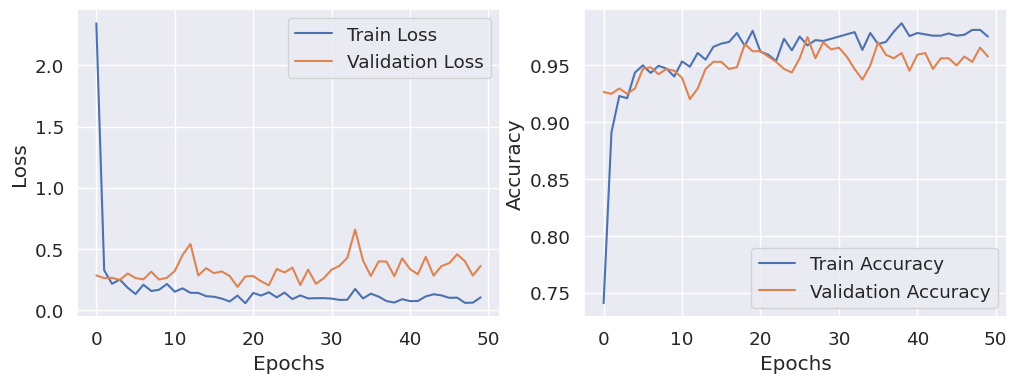

In [ ]:
 # Visualize training and validation loss and accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_m2.history['loss'], label='Train Loss')
plt.plot(history_m2.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_m2.history['accuracy'], label='Train Accuracy')
plt.plot(history_m2.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
# Generate predictions for the test set
predictions_m2 = m2.predict(test_generator)

# Use the true labels directly
y_true_m2 = test_generator.labels

# Convert predicted probabilities to class labels
y_pred_m2 = np.argmax(predictions_m2, axis=1)

# Classification Report
class_report_m2 = classification_report(y_true_m2, y_pred_m2)
print("Classification Report:")
print(class_report_m2)

25/25 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.95       100
           1       0.97      0.99      0.98       100
           2       0.99      1.00      1.00       100
           3       0.96      1.00      0.98       100
           4       0.99      0.97      0.98       100
           5       0.97      0.98      0.98       100
           6       0.96      0.99      0.98       100
           7       0.98      0.94      0.96       100

    accuracy                           0.97       800
   macro avg       0.98      0.97      0.97       800
weighted avg       0.98      0.97      0.97       800



In [ ]:
from sklearn.metrics import accuracy_score

# Calculate the accuracy
accuracy_m2 = accuracy_score(y_true_m2, y_pred_m2)

# Print the accuracy
print("Accuracy:", accuracy_m2)

Accuracy: 0.975


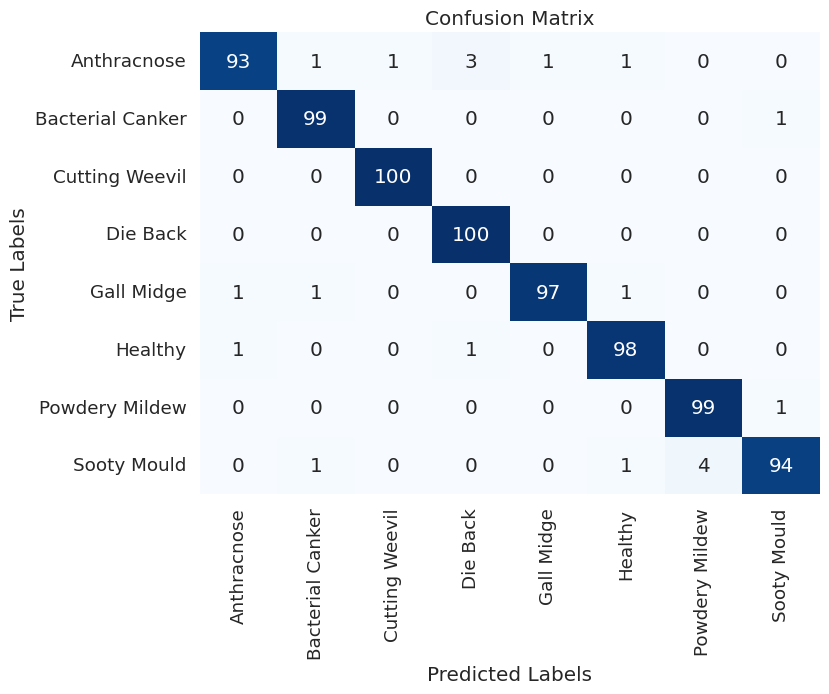

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
confusion_m2= confusion_matrix(y_true_m2, y_pred_m2)

# Define class labels (you can get them from the generator)
class_labels = list(test_generator.class_indices.keys())

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)
sns.heatmap(confusion_m2, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step


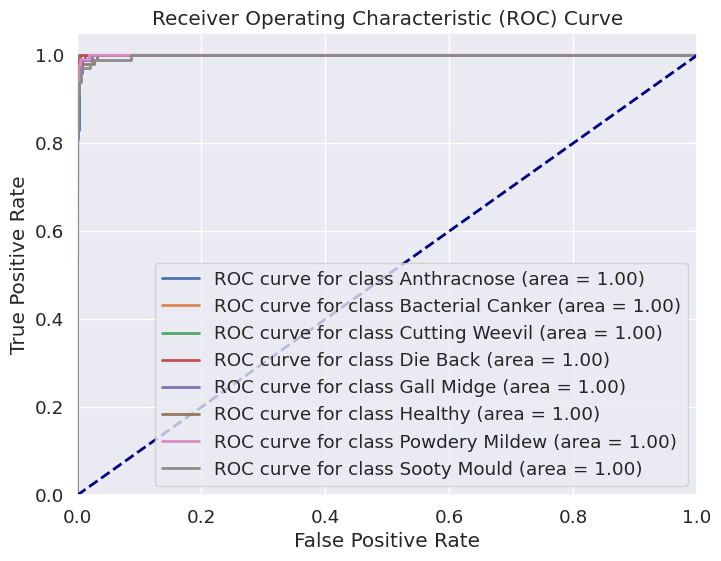

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Generate predictions for the test set
predictions_m2 = m2.predict(test_generator)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(class_labels)):
    fpr[i], tpr[i], _ = roc_curve(y_true_m2, predictions_m2[:, i], pos_label=i)
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting the ROC curve
plt.figure(figsize=(8, 6))
for i in range(len(class_labels)):
    plt.plot(fpr[i], tpr[i], lw=2, label='ROC curve for class {0} (area = {1:0.2f})'.format(class_labels[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


# InceptionV3

In [ ]:
# library

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Load pre-trained VGG16 model
model_InceptionV3 = InceptionV3(weights='imagenet',
                   include_top=False,
                   input_shape=(224, 224, 3))

for layer in model_InceptionV3.layers:
    layer.trainable = False


# Build custom classification head
m3 = Sequential()
m3.add(model_InceptionV3)
m3.add(Flatten())
m3.add(Dense(256, activation='relu'))
m3.add(Dropout(0.5))
m3.add(Dense(8, activation='softmax'))

# Compile the model
optimizer = Adam(learning_rate=0.001)


m3.compile(loss='categorical_crossentropy',
              optimizer=optimizer,
              metrics=['accuracy'])

# Train the model
history_m3 = m3.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator
)



87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 30s 163ms/step - accuracy: 0.5422 - loss: 11.5669 - val_accuracy: 0.8047 - val_loss: 0.5401
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - accuracy: 0.8443 - loss: 0.4466 - val_accuracy: 0.8516 - val_loss: 0.4341
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - accuracy: 0.8463 - loss: 0.4573 - val_accuracy: 0.8656 - val_loss: 0.4844
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 93ms/step - accuracy: 0.8808 - loss: 0.3454 - val_accuracy: 0.8672 - val_loss: 0.4664
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 101ms/step - accuracy: 0.9145 - loss: 0.2705 - val_accuracy: 0.8828 - val_loss: 0.3917
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - accuracy: 0.9069 - loss: 0.2820 - val_accuracy: 0.8828 - val_loss: 0.4260
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 90ms/step - accuracy: 0.9055 - loss: 0.2641 - val_accuracy: 0.8750 - val_loss: 0.3362
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 84ms/step - a

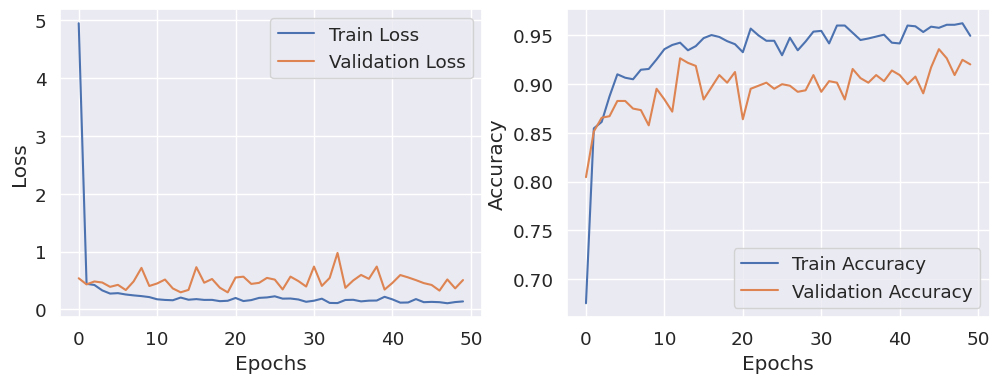

In [ ]:
 # Visualize training and validation loss and accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_m3.history['loss'], label='Train Loss')
plt.plot(history_m3.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_m3.history['accuracy'], label='Train Accuracy')
plt.plot(history_m3.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
# Generate predictions for the test set
predictions_m3 = m3.predict(test_generator)

# Use the true labels directly
y_true_m3 = test_generator.labels

# Convert predicted probabilities to class labels
y_pred_m3 = np.argmax(predictions_m3, axis=1)

# Classification Report
class_report_m3 = classification_report(y_true_m3, y_pred_m3)
print("Classification Report:")
print(class_report_m3)

25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       100
           1       0.93      1.00      0.97       100
           2       1.00      1.00      1.00       100
           3       0.98      0.98      0.98       100
           4       0.96      0.95      0.95       100
           5       0.96      0.97      0.97       100
           6       0.97      0.95      0.96       100
           7       0.95      0.92      0.93       100

    accuracy                           0.97       800
   macro avg       0.97      0.97      0.97       800
weighted avg       0.97      0.97      0.97       800



In [ ]:
from sklearn.metrics import accuracy_score

# Calculate the accuracy
accuracy_m3 = accuracy_score(y_true_m3, y_pred_m3)

# Print the accuracy
print("Accuracy:", accuracy_m3)

Accuracy: 0.96625


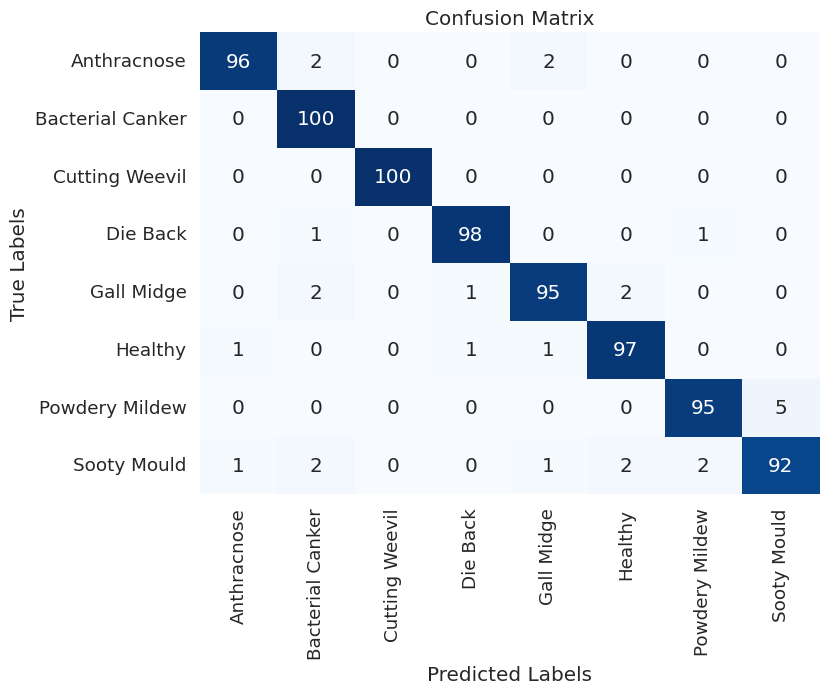

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
confusion_m3= confusion_matrix(y_true_m3, y_pred_m3)

# Define class labels (you can get them from the generator)
class_labels = list(test_generator.class_indices.keys())

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)
sns.heatmap(confusion_m3, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step


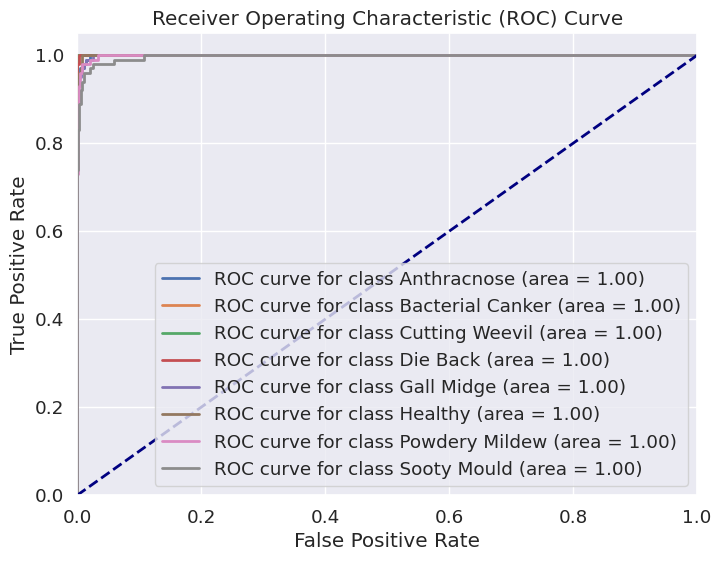

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Generate predictions for the test set using the Keras model 'm3'
predictions_m3 = m3.predict(test_generator) # Use m3 instead of confusion_m3

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(class_labels)):
    fpr[i], tpr[i], _ = roc_curve(y_true_m3, predictions_m3[:, i], pos_label=i)
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting the ROC curve
plt.figure(figsize=(8, 6))
for i in range(len(class_labels)):
    plt.plot(fpr[i], tpr[i], lw=2, label='ROC curve for class {0} (area = {1:0.2f})'.format(class_labels[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

# DenseNet201

In [ ]:
# library

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Load pre-trained VGG16 model
model_DenseNet201 = DenseNet201(weights='imagenet',
                   include_top=False,
                   input_shape=(224, 224, 3))

for layer in model_DenseNet201.layers:
    layer.trainable = False


# Build custom classification head
m4 = Sequential()
m4.add(model_DenseNet201)
m4.add(Flatten())
m4.add(Dense(256, activation='relu'))
m4.add(Dropout(0.5))
m4.add(Dense(8, activation='softmax'))

# Compile the model
optimizer = Adam(learning_rate=0.001)


m4.compile(loss='categorical_crossentropy',
              optimizer=optimizer,
              metrics=['accuracy'])

# Train the model
history_m4 = m4.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator
)



74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 72s 347ms/step - accuracy: 0.6541 - loss: 4.6500 - val_accuracy: 0.8922 - val_loss: 0.4275
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 13s 155ms/step - accuracy: 0.9192 - loss: 0.2481 - val_accuracy: 0.9281 - val_loss: 0.2882
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 13s 157ms/step - accuracy: 0.9331 - loss: 0.2052 - val_accuracy: 0.9328 - val_loss: 0.3496
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 13s 159ms/step - accuracy: 0.9416 - loss: 0.2143 - val_accuracy: 0.9375 - val_loss: 0.2605
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 13s 162ms/step - accuracy: 0.9482 - loss: 0.1736 - val_accuracy: 0.9438 - val_loss: 0.2451
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 13s 162ms/step - accuracy: 0.9505 - loss: 0.1748 - val_accuracy: 0.9531 - val_loss: 0.1575
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 13s 164ms/step - accuracy: 0.9537 - loss: 0.1635 - val_accuracy: 0.9375 - val_loss: 0.2309
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 20s 161m

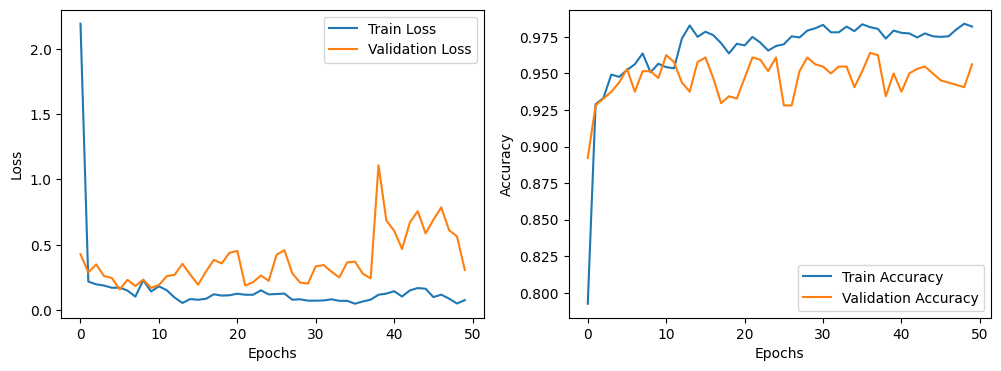

In [ ]:
 # Visualize training and validation loss and accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_m4.history['loss'], label='Train Loss')
plt.plot(history_m4.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_m4.history['accuracy'], label='Train Accuracy')
plt.plot(history_m4.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
# Generate predictions for the test set
predictions_m4 = m4.predict(test_generator)

# Use the true labels directly
y_true_m4 = test_generator.labels

# Convert predicted probabilities to class labels
y_pred_m4 = np.argmax(predictions_m4, axis=1)

# Classification Report
class_report_m4 = classification_report(y_true_m4, y_pred_m4)
print("Classification Report:")
print(class_report_m4)

25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 106ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.92      0.94       100
           1       1.00      0.99      0.99       100
           2       1.00      1.00      1.00       100
           3       0.98      1.00      0.99       100
           4       0.96      0.96      0.96       100
           5       0.96      1.00      0.98       100
           6       0.98      0.95      0.96       100
           7       0.95      0.98      0.97       100

    accuracy                           0.97       800
   macro avg       0.98      0.97      0.97       800
weighted avg       0.98      0.97      0.97       800



In [ ]:
from sklearn.metrics import accuracy_score

# Calculate the accuracy
accuracy_m4 = accuracy_score(y_true_m4, y_pred_m4)

# Print the accuracy
print("Accuracy:", accuracy_m4)

Accuracy: 0.975


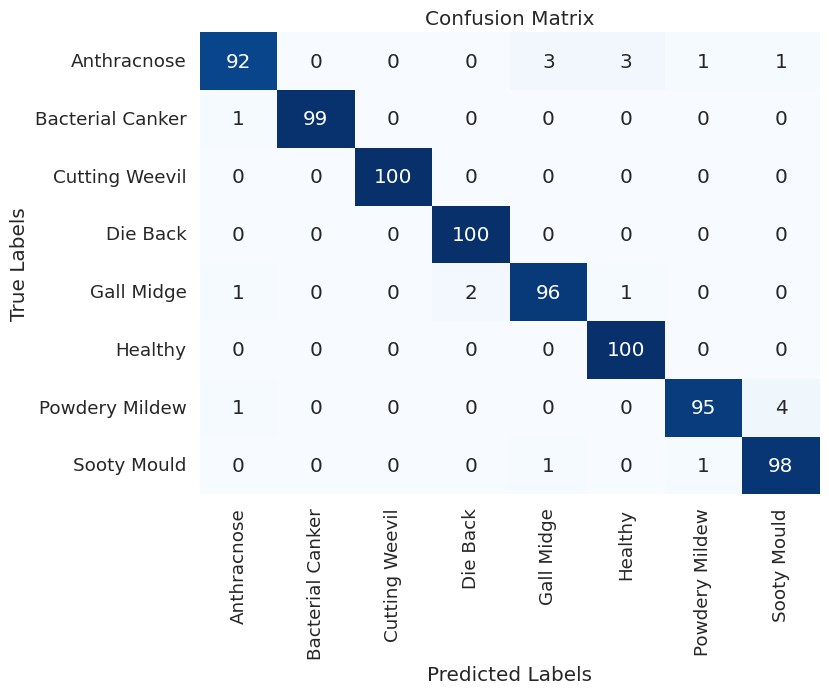

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
confusion_m4 = confusion_matrix(y_true_m4, y_pred_m4)

# Define class labels (you can get them from the generator)
class_labels = list(test_generator.class_indices.keys())

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)
sns.heatmap(confusion_m4, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Generate predictions for the test set
predictions_m4 = m4.predict(test_generator)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(class_labels)):
    fpr[i], tpr[i], _ = roc_curve(y_true_m4, predictions_m4[:, i], pos_label=i)
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting the ROC curve
plt.figure(figsize=(8, 6))
for i in range(len(class_labels)):
    plt.plot(fpr[i], tpr[i], lw=2, label='ROC curve for class {0} (area = {1:0.2f})'.format(class_labels[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


# SqueezeNet

In [ ]:
!pip install torch torchvision

In [ ]:
# Install keras-squeezenet if not installed
!pip install keras-squeezenet

  Preparing metadata (setup.py) ... done
  Created wheel for keras-squeezenet: filename=keras_squeezenet-0.4-py3-none-any.whl size=3572 sha256=237e4f949dc8c477cc6f1dd4ec513ea8ffd36928cc888dfb2cbadf4654a41ec7
  Stored in directory: /root/.cache/pip/wheels/c5/8b/bb/eff0cb7dd0853f712e4ace15fbc569abd6141321ded205abdf
Successfully built keras-squeezenet


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Activation, concatenate, Dropout, GlobalAveragePooling2D

# Model parameters
input_shape = (224, 224, 3)
num_classes = 8

# Define Fire Module
def fire_module(x, squeeze, expand):
    squeeze_layer = Conv2D(squeeze, (1, 1), activation='relu', padding='same')(x)
    expand_1x1 = Conv2D(expand, (1, 1), activation='relu', padding='same')(squeeze_layer)
    expand_3x3 = Conv2D(expand, (3, 3), activation='relu', padding='same')(squeeze_layer)
    return concatenate([expand_1x1, expand_3x3])

# Define SqueezeNet Model
def SqueezeNet(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    x = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = fire_module(x, 16, 64)
    x = fire_module(x, 16, 64)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = fire_module(x, 32, 128)
    x = fire_module(x, 32, 128)
    x = MaxPooling2D(pool_size=(2, 2))(x)

    x = fire_module(x, 48, 192)
    x = fire_module(x, 48, 192)
    x = fire_module(x, 64, 256)
    x = fire_module(x, 64, 256)

    x = Dropout(0.5)(x)
    x = Conv2D(num_classes, (1, 1), padding='same')(x)  # Removed activation
    x = GlobalAveragePooling2D()(x)
    outputs = Activation('softmax')(x)

    model = Model(inputs, outputs)
    return model

# Define model
model = SqueezeNet(input_shape=input_shape, num_classes=num_classes)

# Compile model
optimizer = tf.keras.optimizers.SGD(learning_rate= 1e-4)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])



# Print model summary
model.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_104 (Conv2D)       │ (None, 224, 224, 64)   │          1,792 │ input_layer_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_12          │ (None, 112, 112, 64)   │              0 │ conv2d_104[0][0]       │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_105 (Conv2D)       │ (None, 112, 112, 16)   │          1,040 │ max_pooling2d_12[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_106 (Conv2D)       │ (None, 112, 112, 64)   │          1,088 │ conv2d_105[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_107 (Conv2D)       │ (None, 112, 112, 64)   │          9,280 │ conv2d_105[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_32            │ (None, 112, 112, 128)  │              0 │ conv2d_106[0][0],      │
│ (Concatenate)             │                        │                │ conv2d_107[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_108 (Conv2D)       │ (None, 112, 112, 16)   │          2,064 │ concatenate_32[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_109 (Conv2D)       │ (None, 112, 112, 64)   │          1,088 │ conv2d_108[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_110 (Conv2D)       │ (None, 112, 112, 64)   │          9,280 │ conv2d_108[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_33            │ (None, 112, 112, 128)  │              0 │ conv2d_109[0][0],      │
│ (Concatenate)             │                        │                │ conv2d_110[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_13          │ (None, 56, 56, 128)    │              0 │ concatenate_33[0][0]   │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_111 (Conv2D)       │ (None, 56, 56, 32)     │          4,128 │ max_pooling2d_13[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_112 (Conv2D)       │ (None, 56, 56, 128)    │          4,224 │ conv2d_111[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_113 (Conv2D)       │ (None, 56, 56, 128)    │         36,992 │ conv2d_111[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_34            │ (None, 56, 56, 256)    │              0 │ conv2d_112[0][0],      │
│ (Concatenate)             │                        │                │ conv2d_113[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_114 (Conv2D)  

 Total params: 726,600 (2.77 MB)

 Trainable params: 726,600 (2.77 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

# Hyperparameters
batch_size = 32
epochs = 50


# Train the Model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    epochs=epochs
)


Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 19s 166ms/step - accuracy: 0.1229 - loss: 2.0794 - val_accuracy: 0.1250 - val_loss: 2.0794
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 333us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 150ms/step - accuracy: 0.1199 - loss: 2.0794 - val_accuracy: 0.1250 - val_loss: 2.0794
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 127us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 148ms/step - accuracy: 0.1198 - loss: 2.0794 - val_accuracy: 0.1250 - val_loss: 2.0794
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 197us/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 20s 144ms/step - accuracy: 0.1185 - loss: 2.0794 - val_accuracy: 0.1250 - val_loss: 2.0794
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 9/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 20s 146ms/step - accuracy: 0.1331 - loss: 2.0794 - val_accuracy: 0.1250 

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
# Generate predictions for the test set
predictions_m1 = model.predict(test_generator)

# Use the true labels directly
y_true_m1 = test_generator.labels

# Convert predicted probabilities to class labels
y_pred_m1 = np.argmax(predictions_m1, axis=1)

# Classification Report
class_report_m1 = classification_report(y_true_m1, y_pred_m1)
print("Classification Report:")
print(class_report_m1)




from sklearn.metrics import accuracy_score

# Calculate the accuracy
accuracy_m1 = accuracy_score(y_true_m1, y_pred_m1)

# Print the accuracy
print("Accuracy:", accuracy_m1)

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       100
           1       0.12      1.00      0.22       100
           2       0.00      0.00      0.00       100
           3       0.00      0.00      0.00       100
           4       0.00      0.00      0.00       100
           5       0.00      0.00      0.00       100
           6       0.00      0.00      0.00       100
           7       0.00      0.00      0.00       100

    accuracy                           0.12       800
   macro avg       0.02      0.12      0.03       800
weighted avg       0.02      0.12      0.03       800

Accuracy: 0.125


# MobileNetV3

In [10]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, DepthwiseConv2D, BatchNormalization, ReLU, GlobalAveragePooling2D,
    Dense, Dropout, Add
)

# Define the Squeeze-and-Excitation block
def squeeze_and_excite_block(inputs, reduction_ratio=4):
    filters = inputs.shape[-1]
    reduced_filters = filters // reduction_ratio

    x = GlobalAveragePooling2D()(inputs)
    x = Dense(reduced_filters, activation='relu')(x)
    x = Dense(filters, activation='sigmoid')(x)

    return tf.keras.layers.multiply([inputs, x])

# Bottleneck Block with Integer Casting
def bottleneck_block(inputs, expansion, out_channels, kernel_size, stride, use_se):
    in_channels = inputs.shape[-1]

    # Step 1: Expansion
    x = Conv2D(int(in_channels * expansion), (1, 1), strides=1, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # Step 2: Depthwise Convolution
    x = DepthwiseConv2D(kernel_size, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # Step 3: Squeeze-and-Excitation (optional)
    if use_se:
        x = squeeze_and_excite_block(x)

    # Step 4: Pointwise Projection
    x = Conv2D(out_channels, (1, 1), strides=1, padding='same')(x)
    x = BatchNormalization()(x)

    # Add residual connection if input and output shapes match
    if stride == 1 and in_channels == out_channels:
        x = Add()([inputs, x])

    return x


# Define MobileNetV3Large Architecture
def MobileNetV3Large(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    # Initial Convolution
    x = Conv2D(16, (3, 3), strides=2, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # Bottleneck Blocks
    x = bottleneck_block(x, expansion=1, out_channels=16, kernel_size=(3, 3), stride=1, use_se=False)
    x = bottleneck_block(x, expansion=4, out_channels=24, kernel_size=(3, 3), stride=2, use_se=False)
    x = bottleneck_block(x, expansion=3, out_channels=24, kernel_size=(3, 3), stride=1, use_se=False)
    x = bottleneck_block(x, expansion=3, out_channels=40, kernel_size=(5, 5), stride=2, use_se=True)
    x = bottleneck_block(x, expansion=3, out_channels=40, kernel_size=(5, 5), stride=1, use_se=True)
    x = bottleneck_block(x, expansion=6, out_channels=80, kernel_size=(3, 3), stride=2, use_se=False)
    x = bottleneck_block(x, expansion=2.5, out_channels=80, kernel_size=(3, 3), stride=1, use_se=False)
    x = bottleneck_block(x, expansion=2.3, out_channels=80, kernel_size=(3, 3), stride=1, use_se=False)
    x = bottleneck_block(x, expansion=6, out_channels=112, kernel_size=(3, 3), stride=1, use_se=True)
    x = bottleneck_block(x, expansion=6, out_channels=112, kernel_size=(3, 3), stride=1, use_se=True)
    x = bottleneck_block(x, expansion=6, out_channels=160, kernel_size=(5, 5), stride=2, use_se=True)
    x = bottleneck_block(x, expansion=6, out_channels=160, kernel_size=(5, 5), stride=1, use_se=True)
    x = bottleneck_block(x, expansion=6, out_channels=160, kernel_size=(5, 5), stride=1, use_se=True)

    # Head of the network
    x = Conv2D(960, (1, 1), strides=1, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.2)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model

# Instantiate the model
input_shape = (224, 224, 3)
num_classes = 8
model = MobileNetV3Large(input_shape, num_classes)

# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

# Print model summary
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_14 (Conv2D)        │ (None, 112, 112, 16)   │            448 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_19    │ (None, 112, 112, 16)   │             64 │ conv2d_14[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_13 (ReLU)           │ (None, 112, 112, 16)   │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_15 (Conv2D)        │ (None, 112, 112, 16)   │            272 │ re_lu_13[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_20    │ (None, 112, 112, 16)   │             64 │ conv2d_15[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_14 (ReLU)           │ (None, 112, 112, 16)   │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ depthwise_conv2d_6        │ (None, 112, 112, 16)   │            160 │ re_lu_14[0][0]         │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_21    │ (None, 112, 112, 16)   │             64 │ depthwise_conv2d_6[0]… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_15 (ReLU)           │ (None, 112, 112, 16)   │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_16 (Conv2D)        │ (None, 112, 112, 16)   │            272 │ re_lu_15[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_22    │ (None, 112, 112, 16)   │             64 │ conv2d_16[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_3 (Add)               │ (None, 112, 112, 16)   │              0 │ re_lu_13[0][0],        │
│                           │                        │                │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_17 (Conv2D)        │ (None, 112, 112, 64)   │          1,088 │ add_3[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_23    │ (None, 112, 112, 64)   │            256 │ conv2d_17[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_16 (ReLU)      

 Total params: 2,960,056 (11.29 MB)

 Trainable params: 2,937,080 (11.20 MB)

 Non-trainable params: 22,976 (89.75 KB)

In [11]:

# Train the model
history_suff = model.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator
)



Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 113s 552ms/step - accuracy: 0.5655 - loss: 1.1855 - val_accuracy: 0.1250 - val_loss: 2.3008
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 42s 496ms/step - accuracy: 0.8168 - loss: 0.4830 - val_accuracy: 0.1250 - val_loss: 2.7602
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 79s 465ms/step - accuracy: 0.8351 - loss: 0.5028 - val_accuracy: 0.1250 - val_loss: 3.6259
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 40s 471ms/step - accuracy: 0.8806 - loss: 0.3328 - val_accuracy: 0.1250 - val_loss: 3.6663
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 41s 467ms/step - accuracy: 0.8859 - loss: 0.3267 - val_accuracy: 0.1250 - val_loss: 3.8606
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 39s 463ms/step - accuracy: 0.8990 - loss: 0.2875 - val_accuracy: 0.1250 - val_loss: 4.1199
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 41s 457ms/step - accuracy: 0.9407 - loss: 0.1932 - val_accuracy: 0.2078 - val_loss: 3.5480
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 42s 456ms/step - accuracy: 0.9426 - loss: 0.1822 - val_acc

In [12]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
# Generate predictions for the test set
predictions_m1 = model.predict(test_generator)

# Use the true labels directly
y_true_m1 = test_generator.labels

# Convert predicted probabilities to class labels
y_pred_m1 = np.argmax(predictions_m1, axis=1)

# Classification Report
class_report_m1 = classification_report(y_true_m1, y_pred_m1)
print("Classification Report:")
print(class_report_m1)




from sklearn.metrics import accuracy_score

# Calculate the accuracy
accuracy_m1 = accuracy_score(y_true_m1, y_pred_m1)

# Print the accuracy
print("Accuracy:", accuracy_m1)

25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.84      0.91       100
           1       0.88      0.91      0.89       100
           2       0.99      0.98      0.98       100
           3       1.00      1.00      1.00       100
           4       0.96      0.82      0.89       100
           5       0.94      0.93      0.93       100
           6       0.98      0.83      0.90       100
           7       0.69      0.99      0.81       100

    accuracy                           0.91       800
   macro avg       0.93      0.91      0.92       800
weighted avg       0.93      0.91      0.92       800

Accuracy: 0.9125


#  ShuffleNetV2

In [10]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, DepthwiseConv2D, BatchNormalization, ReLU, GlobalAveragePooling2D, Dense, Input, Add, Lambda, Concatenate
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

def channel_shuffle(x, groups):
    height, width, in_channels = x.shape[1:]
    channels_per_group = in_channels // groups
    x = tf.reshape(x, [-1, height, width, groups, channels_per_group])
    x = tf.transpose(x, [0, 1, 2, 4, 3])
    x = tf.reshape(x, [-1, height, width, in_channels])
    return x

def shuffle_unit(inputs, out_channels, stride):
    half_channels = out_channels // 2

    if stride == 1:
        # Split input into two equal channels
        x1, x2 = Lambda(lambda z: tf.split(z, num_or_size_splits=2, axis=-1))(inputs)
    else:
        # When stride=2, downsample x1 with depthwise convolution
        x1 = DepthwiseConv2D(3, strides=2, padding='same', use_bias=False)(inputs)
        x1 = BatchNormalization()(x1)
        x1 = Conv2D(half_channels, 1, padding='same', use_bias=False)(x1)
        x1 = BatchNormalization()(x1)
        x1 = ReLU()(x1)

        x2 = Conv2D(half_channels, 1, padding='same', use_bias=False)(inputs)
        x2 = BatchNormalization()(x2)
        x2 = ReLU()(x2)

    # Apply depthwise convolution to x2
    x2 = DepthwiseConv2D(3, strides=stride, padding='same', use_bias=False)(x2)
    x2 = BatchNormalization()(x2)
    x2 = Conv2D(half_channels, 1, padding='same', use_bias=False)(x2)
    x2 = BatchNormalization()(x2)
    x2 = ReLU()(x2)

    # Concatenate x1 and x2, then shuffle channels
    x = Concatenate()([x1, x2])
    x = Lambda(lambda z: channel_shuffle(z, 2))(x)
    return x


def ShuffleNetV2(input_shape=(224, 224, 3), num_classes=8):
    inputs = Input(shape=input_shape)
    x = Conv2D(24, 3, strides=2, padding='same', use_bias=False)(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    x = shuffle_unit(x, 116, stride=2)
    x = shuffle_unit(x, 116, stride=1)
    x = shuffle_unit(x, 232, stride=2)
    x = shuffle_unit(x, 232, stride=1)
    x = shuffle_unit(x, 464, stride=2)
    x = shuffle_unit(x, 464, stride=1)

    x = GlobalAveragePooling2D()(x)
    x = Dense(8, activation='softmax')(x)

    models = Model(inputs, x)
    return models

models = ShuffleNetV2()
models.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

models.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_13 (Conv2D)        │ (None, 112, 112, 24)   │            648 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_22    │ (None, 112, 112, 24)   │             96 │ conv2d_13[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_13 (ReLU)           │ (None, 112, 112, 24)   │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_15 (Conv2D)        │ (None, 112, 112, 58)   │          1,392 │ re_lu_13[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_25    │ (None, 112, 112, 58)   │            232 │ conv2d_15[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ re_lu_15 (ReLU)           │ (None, 112, 112, 58)   │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ depthwise_conv2d_9        │ (None, 56, 56, 24)     │            216 │ re_lu_13[0][0]         │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ depthwise_conv2d_10       │ (None, 56, 56, 58)     │            522 │ re_lu_15[0][0]         │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_23    │ (None, 56, 56, 24)     │             96 │ depthwise_conv2d_9[0]… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_26    │ (None, 56, 56, 58)     │            232 │ depthwise_conv2d_10[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_14 (Conv2D)        │ (None, 56, 56, 58)     │          1,392 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_16 (Conv2D)        │ (None, 56, 56, 58)     │          3,364 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_24    │ (None, 56, 56, 58)     │            232 │ conv2d_14[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_27    │ (None, 56, 56, 58)     │            232 │ conv2d_16[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├──────────────────────

 Total params: 304,984 (1.16 MB)

 Trainable params: 299,320 (1.14 MB)

 Non-trainable params: 5,664 (22.12 KB)

In [11]:

# Train the model
history_suff = models.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator
)



Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 70s 476ms/step - accuracy: 0.6404 - loss: 1.0324 - val_accuracy: 0.1250 - val_loss: 2.0917
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 40s 454ms/step - accuracy: 0.9032 - loss: 0.3120 - val_accuracy: 0.1250 - val_loss: 2.1329
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 39s 436ms/step - accuracy: 0.9318 - loss: 0.2293 - val_accuracy: 0.1250 - val_loss: 2.2268
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 39s 437ms/step - accuracy: 0.9322 - loss: 0.2001 - val_accuracy: 0.1250 - val_loss: 2.3711
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 40s 434ms/step - accuracy: 0.9433 - loss: 0.1602 - val_accuracy: 0.1266 - val_loss: 2.4185
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 39s 439ms/step - accuracy: 0.9623 - loss: 0.1064 - val_accuracy: 0.1797 - val_loss: 3.2183
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 39s 452ms/step - accuracy: 0.9686 - loss: 0.0947 - val_accuracy: 0.5828 - val_loss: 1.0638
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 41s 448ms/step - accuracy: 0.9719 - loss: 0.0814 - val_accu

In [12]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
# Generate predictions for the test set
predictions_m1 = models.predict(test_generator)

# Use the true labels directly
y_true_m1 = test_generator.labels

# Convert predicted probabilities to class labels
y_pred_m1 = np.argmax(predictions_m1, axis=1)

# Classification Report
class_report_m1 = classification_report(y_true_m1, y_pred_m1)
print("Classification Report:")
print(class_report_m1)




from sklearn.metrics import accuracy_score

# Calculate the accuracy
accuracy_m1 = accuracy_score(y_true_m1, y_pred_m1)

# Print the accuracy
print("Accuracy:", accuracy_m1)

25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.82      0.88       100
           1       0.83      1.00      0.91       100
           2       0.99      1.00      1.00       100
           3       1.00      0.95      0.97       100
           4       0.90      0.94      0.92       100
           5       0.96      1.00      0.98       100
           6       1.00      0.91      0.95       100
           7       0.98      0.96      0.97       100

    accuracy                           0.95       800
   macro avg       0.95      0.95      0.95       800
weighted avg       0.95      0.95      0.95       800

Accuracy: 0.9475
